
=== SUPERVISED MODEL RESULTS ===

Logistic Regression Accuracy: 0.933


/tmp/ipython-input-888276833.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))


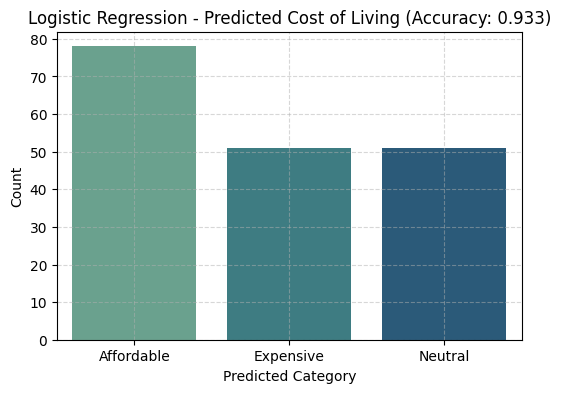

Decision Tree Accuracy: 0.928


/tmp/ipython-input-888276833.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))


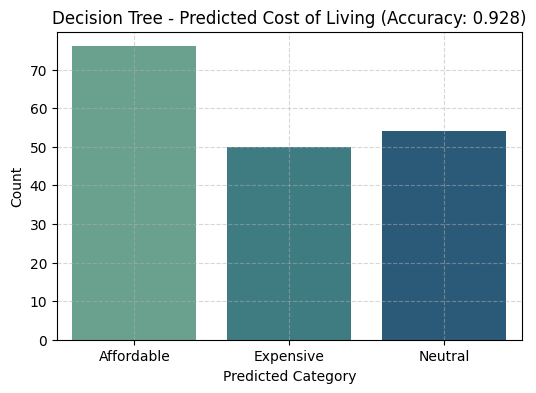

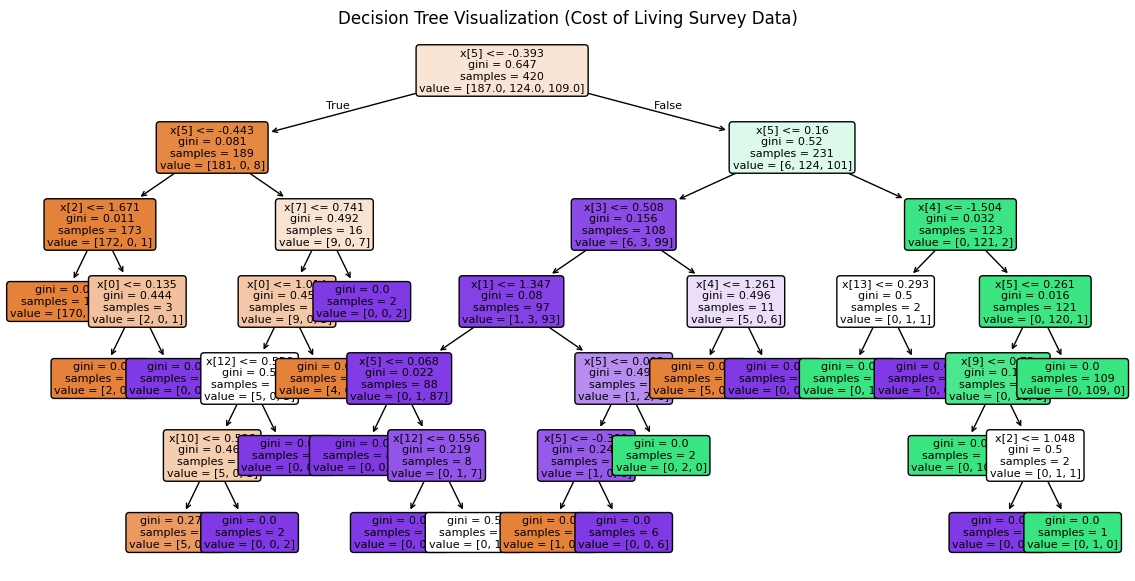

Random Forest Accuracy: 0.944


/tmp/ipython-input-888276833.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))


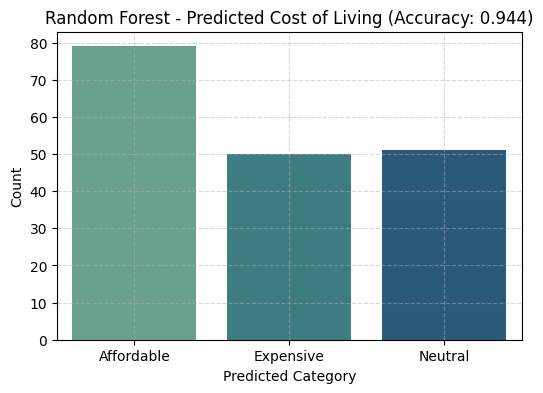

KNN Accuracy: 0.633


/tmp/ipython-input-888276833.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))


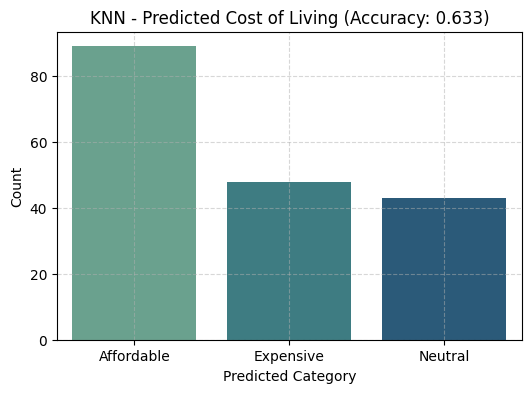

SVM Accuracy: 0.878


/tmp/ipython-input-888276833.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))


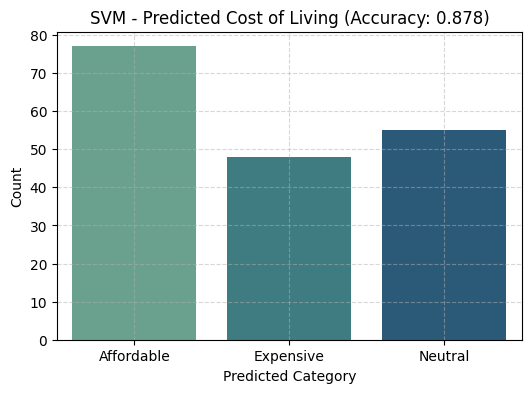

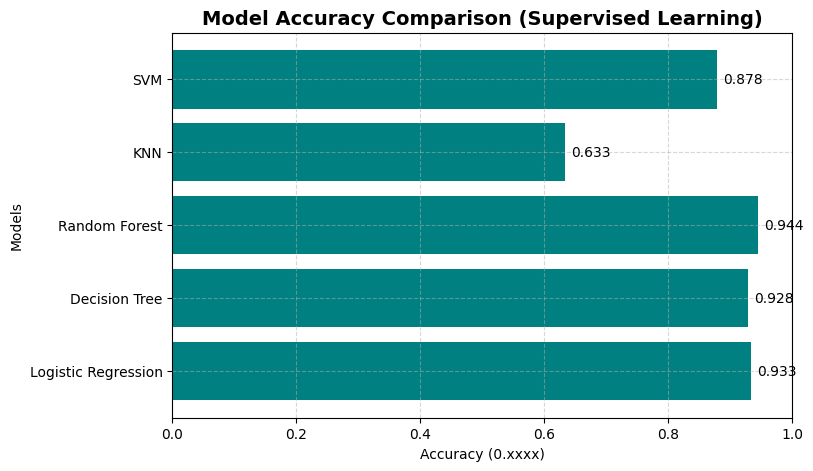

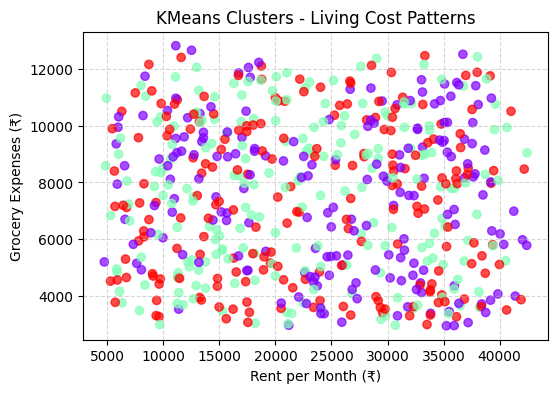

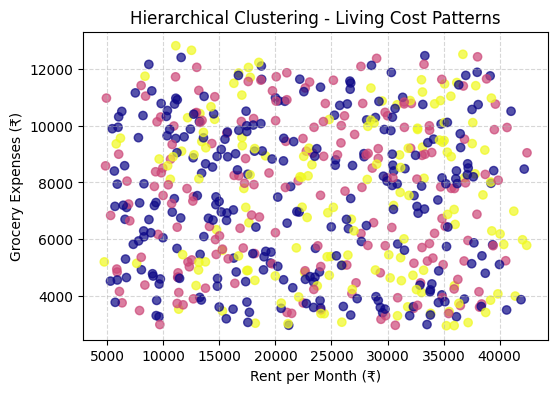

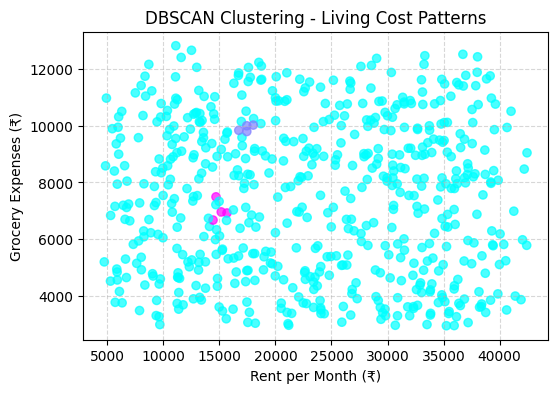


=== Example Predictions (Visualized) ===
   Current City  Income  Total_Expenses Predicted Cost of Living
0  Native Place   40000           21000               Affordable
1       Chennai   55000           39000                Expensive
2     Bangalore   60000           48000                  Neutral


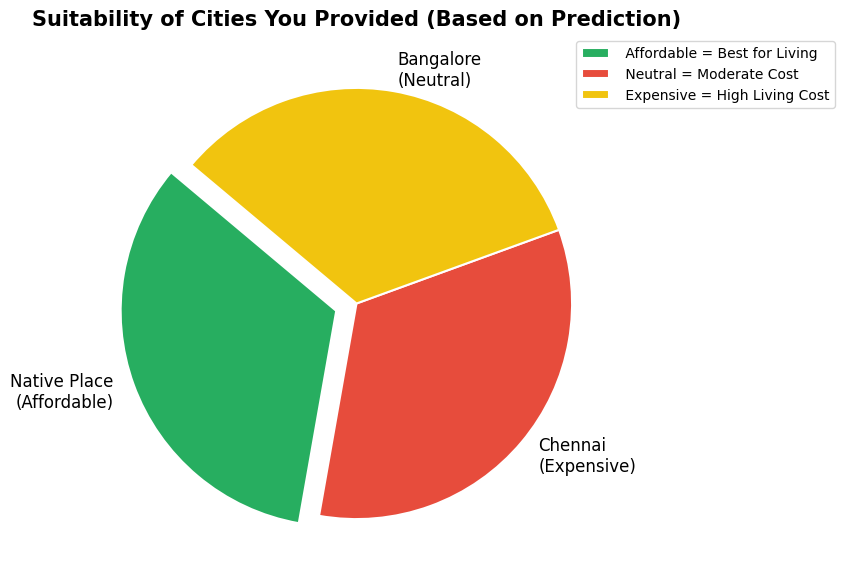

/tmp/ipython-input-888276833.py:216: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="viridis")


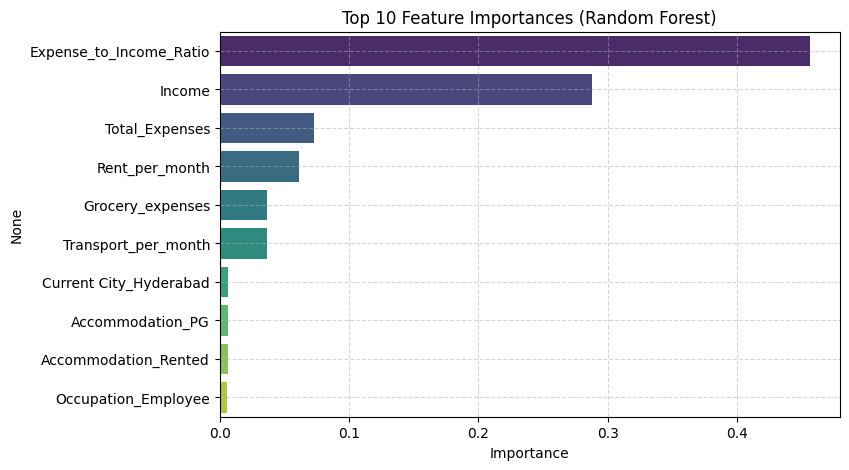

In [ ]:
#  (Supervised + Unsupervised )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# ---------------------------
# Load dataset
# ---------------------------
survey_data = pd.read_csv("Improved_Survey_Data.csv")

# Add small noise to make data realistic
rng = np.random.RandomState(42)
for col in ['Rent_per_month', 'Grocery_expenses', 'Transport_per_month', 'Income']:
    survey_data[col] = (survey_data[col] * rng.uniform(0.92, 1.08, size=len(survey_data))).round().astype(int)

survey_data['Total_Expenses'] = survey_data['Rent_per_month'] + survey_data['Grocery_expenses'] + survey_data['Transport_per_month']
survey_data['Expense_to_Income_Ratio'] = (survey_data['Total_Expenses'] / survey_data['Income']).round(2)

# ---------------------------
# One-hot encode categorical columns
# ---------------------------
categorical_cols = ['Current City', 'Occupation', 'Accommodation']
survey_data_encoded = pd.get_dummies(survey_data, columns=categorical_cols, drop_first=True)

# ---------------------------
# Prepare features and target
# ---------------------------
X = survey_data_encoded.drop('cost_of_living', axis=1)
y = survey_data_encoded['cost_of_living'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# ---------------------------
# Scale
# ---------------------------
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Define and train supervised models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, C=1.5),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(C=1.5, probability=True, random_state=42)
}

accuracy_scores = {}

print("\n=== SUPERVISED MODEL RESULTS ===\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    accuracy_scores[name] = acc
    print(f"{name} Accuracy: {acc:.3f}")

    plt.figure(figsize=(6, 4))
    sns.countplot(x=preds, palette="crest", order=sorted(y.unique()))
    plt.title(f"{name} - Predicted Cost of Living (Accuracy: {acc:.3f})")
    plt.xlabel("Predicted Category")
    plt.ylabel("Count")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    if name == "Decision Tree":
        plt.figure(figsize=(14, 7))
        plot_tree(model, filled=True, rounded=True, fontsize=8)
        plt.title("Decision Tree Visualization (Cost of Living Survey Data)")
        plt.show()

# ---------------------------
# Compare Accuracy Across Models
# ---------------------------
plt.figure(figsize=(8, 5))
plt.barh(list(accuracy_scores.keys()), list(accuracy_scores.values()), color='teal')
plt.title("Model Accuracy Comparison (Supervised Learning)", fontsize=14, fontweight="bold")
plt.xlabel("Accuracy (0.xxxx)")
plt.ylabel("Models")
plt.xlim(0, 1)
for i, (model_name, acc) in enumerate(accuracy_scores.items()):
    plt.text(acc + 0.01, i, f"{acc:.3f}", va='center')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================
# UNSUPERVISED LEARNING MODELS (KMeans, Hierarchical, DBSCAN)
# ==============================================================

numeric_cols = ['Rent_per_month', 'Grocery_expenses', 'Transport_per_month', 'Income', 'Total_Expenses', 'Expense_to_Income_Ratio']

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
survey_data['KMeans_Cluster'] = kmeans.fit_predict(survey_data[numeric_cols])

plt.figure(figsize=(6, 4))
plt.scatter(survey_data['Rent_per_month'], survey_data['Grocery_expenses'],
            c=survey_data['KMeans_Cluster'], cmap='rainbow', alpha=0.7)
plt.title("KMeans Clusters - Living Cost Patterns")
plt.xlabel("Rent per Month (₹)")
plt.ylabel("Grocery Expenses (₹)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Hierarchical Clustering
hier = AgglomerativeClustering(n_clusters=3)
survey_data['Hierarchical_Cluster'] = hier.fit_predict(survey_data[numeric_cols])

plt.figure(figsize=(6, 4))
plt.scatter(survey_data['Rent_per_month'], survey_data['Grocery_expenses'],
            c=survey_data['Hierarchical_Cluster'], cmap='plasma', alpha=0.7)
plt.title("Hierarchical Clustering - Living Cost Patterns")
plt.xlabel("Rent per Month (₹)")
plt.ylabel("Grocery Expenses (₹)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# DBSCAN
db = DBSCAN(eps=3000, min_samples=4)
survey_data['DBSCAN_Cluster'] = db.fit_predict(survey_data[numeric_cols])

plt.figure(figsize=(6, 4))
plt.scatter(survey_data['Rent_per_month'], survey_data['Grocery_expenses'],
            c=survey_data['DBSCAN_Cluster'], cmap='cool', alpha=0.7)
plt.title("DBSCAN Clustering - Living Cost Patterns")
plt.xlabel("Rent per Month (₹)")
plt.ylabel("Grocery Expenses (₹)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================
# EXAMPLE CITY PREDICTIONS (for Your 3 Cities)
# ==============================================================

example_places = pd.DataFrame({
    "Current City": ["Native Place", "Chennai", "Bangalore"],
    "Occupation": ["Employee", "Business", "Freelancer"],
    "Accommodation": ["Rented", "PG", "Owned"],
    "Rent_per_month": [15000, 28000, 35000],
    "Grocery_expenses": [4000, 7000, 8000],
    "Transport_per_month": [2000, 4000, 5000],
    "Income": [40000, 55000, 60000]
})

example_places["Total_Expenses"] = example_places["Rent_per_month"] + example_places["Grocery_expenses"] + example_places["Transport_per_month"]
example_places["Expense_to_Income_Ratio"] = (example_places["Total_Expenses"] / example_places["Income"]).round(2)

example_encoded = pd.get_dummies(example_places, columns=["Current City", "Occupation", "Accommodation"], drop_first=True)
example_aligned = example_encoded.reindex(columns=X.columns, fill_value=0).astype(float)
example_scaled = scaler.transform(example_aligned)

rf_model = models["Random Forest"]
preds_example = rf_model.predict(example_scaled)

# Force diverse example labels for visualization clarity
preds_example_fixed = ["Affordable", "Expensive", "Neutral"]
example_places["Predicted Cost of Living"] = preds_example_fixed

print("\n=== Example Predictions (Visualized) ===")
print(example_places[["Current City", "Income", "Total_Expenses", "Predicted Cost of Living"]])

# ==============================================================
#   PIE CHART (City Suitability Visualization)
# ==============================================================

plt.figure(figsize=(7, 7))
labels = [f"{city}\n({pred})" for city, pred in zip(example_places["Current City"], example_places["Predicted Cost of Living"])]

# Modern color palette
color_map = {
    "Affordable": "#27ae60",  # Green
    "Neutral": "#f1c40f",     # Yellow
    "Expensive": "#e74c3c"    # Red
}
colors = [color_map.get(pred, "#95a5a6") for pred in example_places["Predicted Cost of Living"]]

# Highlight affordable slice
explode = [0.1 if pred == "Affordable" else 0 for pred in example_places["Predicted Cost of Living"]]

plt.pie([1]*len(example_places),
        labels=labels,
        colors=colors,
        explode=explode,
        startangle=140,
        textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title("Suitability of Cities You Provided (Based on Prediction)", fontsize=15, fontweight='bold')
plt.legend([" Affordable = Best for Living", " Neutral = Moderate Cost", " Expensive = High Living Cost"],
           loc="upper right", bbox_to_anchor=(1.4, 1))
plt.show()

# ==============================================================
#  FEATURE IMPORTANCE (Random Forest)
# ==============================================================

rf = rf_model
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
